In [1]:
from quapack.pyRPE import RobustPhaseEstimation
from quapack.pyRPE.quantum import Q
import numpy as np
import pygsti
%matplotlib inline
import matplotlib.pyplot as plt
import scipy
from pygsti.modelpacks import smq1Q_XY

from jaqalpaq import run
from jaqalpaq import emulator
from jaqalpaq.run import run_jaqal_file, run_jaqal_string, run_jaqal_batch, run_jaqal_circuit, frontend

from jaqalpaq.emulator.unitary import UnitarySerializedEmulator
emulator_backend = UnitarySerializedEmulator()
from qscout.v1.std.noisy import SNLToy1

from jaqalpaq.qsyntax import circuit
from jaqalpaq.generator import generate_jaqal_program

In [2]:
import jaqalpaq.core.block
jaqalpaq.core.block.DEFAULT_NUM_REPEATS = 1
import jaqalpaq.ipc.client
from jaqalpaq.generator import generate_jaqal_program
from jaqalpaq.core.algorithm.walkers import walk_circuit, discover_subcircuits
from jaqalpaq.core.algorithm import expand_subcircuits


import json
def special_emit(circuit, overrides, a=[0]):
    """(internal) Generate Jaqal appropriate for running on the hardware."""
    jaqal = generate_jaqal_program(circuit)
    overrides = overrides or {}
    try:
        overrides["__index__"]
    except KeyError:
        starts = [start for (start, end) in discover_subcircuits(circuit)]
        overrides["__index__"] = [list(walk_circuit(circuit, starts))]
    jaqal = jaqal.replace("from qscout.v1.std usepulses *", "from Calibration_PulseDefinitions.SandboxPulses usepulses *")
    jaqal = "".join((jaqal, "\n// OVERRIDES: ", json.dumps(overrides), "\n"))

    print(a[0])
    a[0] += 1
    print(jaqal)
    return jaqal
jaqalpaq.ipc.client.emit_jaqal_for_hardware = special_emit

In [3]:
def make_cos_subcirc(Q,k,qubit):
    with Q.loop(k):
        Q.Sx(qubit)

def make_sin_subcirc(Q,k,qubit):
    with Q.loop(k+1):
        Q.Sx(qubit)

In [4]:
#def X_gate(theta):
#    H = theta/2 * pygsti.sigmax
#    U = scipy.linalg.expm(-1j * H)
#    return pygsti.unitary_to_pauligate(U)

In [5]:
#target_model = smq1Q_XY.target_model()

In [6]:
max_exp = 8

max_lengths = [2**i for i in range(max_exp+1)]

In [7]:

@circuit
def cos_circs(Q,lengths):
    Q.usepulses("qscout.v1.std")
    q = Q.register(1, name = 'q')
    for k in lengths:
        with Q.subcircuit():
            make_cos_subcirc(Q,k,q[0])
    return(Q)

def cos_circs_labels(lengths):
    labels = []
    for k in max_lengths:
        labels.append("(Sx q[0])^%i"%k)
    return labels

@circuit
def sin_circs(Q,lengths):
    Q.usepulses("qscout.v1.std")
    q = Q.register(1, name = 'q')
    for k in lengths:
        with Q.subcircuit():
            make_sin_subcirc(Q,k,q[0])
    return(Q)

def sin_circs_labels(lengths):
    labels = []
    for k in max_lengths:
        labels.append("(Sx q[0])^%i"%(k+1))
    return labels

@circuit
def all_circs(Q,lengths):
    Q.usepulses("qscout.v1.std")
    q = Q.register(1, name = 'q')
    for k in lengths:
        with Q.subcircuit():
            make_cos_subcirc(Q,k,q[0])
    for k in lengths:
        with Q.subcircuit():
            make_sin_subcirc(Q,k,q[0])
    return(Q)


print(generate_jaqal_program(all_circs(max_lengths)))
print(sin_circs_labels(max_lengths))


all_circuits = all_circs(max_lengths)

#circuits = [make_cos_circ(k) for k in max_lengths]+[make_sin_circ(k) for k in max_lengths]

from qscout.v1.std usepulses *

register q[1]

subcircuit {
	loop 1 {
		Sx q[0]
	}
}
subcircuit {
	loop 2 {
		Sx q[0]
	}
}
subcircuit {
	loop 4 {
		Sx q[0]
	}
}
subcircuit {
	loop 8 {
		Sx q[0]
	}
}
subcircuit {
	loop 16 {
		Sx q[0]
	}
}
subcircuit {
	loop 32 {
		Sx q[0]
	}
}
subcircuit {
	loop 64 {
		Sx q[0]
	}
}
subcircuit {
	loop 128 {
		Sx q[0]
	}
}
subcircuit {
	loop 256 {
		Sx q[0]
	}
}
subcircuit {
	loop 2 {
		Sx q[0]
	}
}
subcircuit {
	loop 3 {
		Sx q[0]
	}
}
subcircuit {
	loop 5 {
		Sx q[0]
	}
}
subcircuit {
	loop 9 {
		Sx q[0]
	}
}
subcircuit {
	loop 17 {
		Sx q[0]
	}
}
subcircuit {
	loop 33 {
		Sx q[0]
	}
}
subcircuit {
	loop 65 {
		Sx q[0]
	}
}
subcircuit {
	loop 129 {
		Sx q[0]
	}
}
subcircuit {
	loop 257 {
		Sx q[0]
	}
}

['(Sx q[0])^2', '(Sx q[0])^3', '(Sx q[0])^5', '(Sx q[0])^9', '(Sx q[0])^17', '(Sx q[0])^33', '(Sx q[0])^65', '(Sx q[0])^129', '(Sx q[0])^257']


In [8]:
#pygsti.remove_duplicates_in_place(circuits)

In [9]:
#Here you would write to file the empty dataset
#pygsti.io.write_empty_dataset('empty_rpe_dataset_1Q_.txt',circuits)

In [10]:
target_theta_x = np.pi/2

In [11]:
#Define the rotation angles used for the simulated dataset
delta_theta_x = 0.05

theta_x = target_theta_x + delta_theta_x

#noisy_model = target_model.copy()
#noisy_model['Gxpi2',0] = X_gate(theta_x)

In [12]:
import scipy.optimize as opt
import time

N = 200

estimated_angles = []
input_amps = []
last_lengths = []

def exp_rpe(amp):
    #Hardcode override for q[0]
    input_amps.append(amp)
    amp_list = [0]*16
    amp_list[2] = amp
    nested_amp_list = [amp_list]


    #For emulator
    delta_theta_x = (np.pi/80*amp) - np.pi/2
    dataset = run.run_jaqal_circuit(all_circuits, backend = SNLToy1(1,rotation_error=delta_theta_x, depolarization = 2e-4), overrides = {'__repeats__': N})
    
    #For experiment
    #dataset = run.run_jaqal_circuit(expand_subcircuits(all_circuits), overrides = {'__repeats__': N, 'j.pd.amp1_coprop_list': nested_amp_list})
    
    probs = {}
    for ii in range(len(max_lengths)):
        probs[cos_circs_labels(max_lengths)[ii]] = dataset.subcircuits[ii].relative_frequency_by_int
        probs[sin_circs_labels(max_lengths)[ii]] = dataset.subcircuits[len(max_lengths)+ii].relative_frequency_by_int
    #print(probs)
    
    experiment = Q()
    for i,k in enumerate(max_lengths):
        sin_circ = sin_circs_labels(max_lengths)[i]
        cos_circ = cos_circs_labels(max_lengths)[i]
        experiment.process_sin(k,(int(probs[sin_circ][1]*N),
                                                int(probs[sin_circ][0]*N)))
        experiment.process_cos(k,(int(probs[cos_circ][0]*N),
                                                int(probs[cos_circ][1]*N)))
    analysis = RobustPhaseEstimation(experiment)
    estimate_errors = np.abs(theta_x - analysis.angle_estimates)
    last_good_estimate_generation = analysis.check_unif_local(historical=True)
    last_lengths.append(2**last_good_estimate_generation)
    angle_estimate = analysis.angle_estimates[last_good_estimate_generation]
    estimated_angles.append(angle_estimate)
    return angle_estimate

def calibrate_pi2(amp):
    theta_meas = exp_rpe(amp[0])
    return np.abs(np.pi/2-theta_meas)

start = time.time()
opt.minimize(fun = calibrate_pi2, x0 = 60, bounds = [(0,100)],tol = (0.01), method = 'COBYLA', options = {'maxiter': 50})
COBYLA_estimated_angles = estimated_angles
end = time.time()
elapsed = end - start
print(COBYLA_estimated_angles)
COBYLA_test_amps = input_amps
print(COBYLA_test_amps)
COBYLA_RPE_last_lengths = last_lengths
print(COBYLA_RPE_last_lengths)
print(elapsed)

start = time.time()
estimated_angles = []
input_amps = []
last_lengths = []
opt.minimize(fun = calibrate_pi2, x0 = 60, bounds = [(0,100)],tol = (0.01), method = 'Nelder-Mead', options = {'maxiter': 50})
end = time.time()
elapsed = end - start
NM_estimated_angles = estimated_angles
print(NM_estimated_angles)
NM_test_amps = input_amps
print(NM_test_amps)
NM_RPE_last_lengths = last_lengths
print(NM_RPE_last_lengths)
print(elapsed)

start = time.time()
estimated_angles = []
input_amps = []
last_lengths = []
opt.minimize(fun = calibrate_pi2, x0 = 60, bounds = [(0,100)],tol = (0.01), method = 'Powell', options = {'maxiter': 50})
end = time.time()
elapsed = end - start
P_estimated_angles = estimated_angles
print(P_estimated_angles)
P_test_amps = input_amps
print(P_test_amps)
P_RPE_last_lengths = last_lengths
print(P_RPE_last_lengths)
print(elapsed)

#estimated_angles = []
#input_amps = []
#last_length = []
#opt.least_squares(fun = calibrate_pi2, x0 = 20, bounds = (0,100), ftol = (0.01),x_scale = [1e-9,100], jac = '3-point')
#LSQ_estimated_angles = estimated_angles
#print(LSQ_estimated_angles)
#LSQ_test_amps = input_amps
#print(LSQ_test_amps)
#LSQ_RPE_last_lengths = last_lengths
#print(LSQ_RPE_last_lengths)


[2.3584519196336036, 2.3962833932617893, 2.320159041289606, 2.2779807235641747, 2.2382419192651914, 2.199969270807069, 2.1619692948754126, 2.122658505330826, 2.081675244579769, 2.041729830775332, 2.0034545043787078, 1.9645825165366093, 1.9251841714709046, 1.8849852456266791, 1.8456807532823571, 1.8067415094618073, 1.76802249267956, 1.7279927549323526, 1.6887042284494165, 1.6488273152262738, 1.6096778092617812, 1.5702547653217163, 1.5311935918159492, 1.5516174809346053, 1.5807027642557747, 1.5655969001623793, 1.573233916845587, 1.5697032912147277, 1.5711944454178688, 1.571943158776962, 1.5710592716222118, 1.5710592716222118]
[60.0, 61.0, 59.0, 58.0, 57.0, 56.0, 55.0, 54.0, 53.0, 52.0, 51.0, 50.0, 49.0, 48.0, 47.0, 46.0, 45.0, 44.0, 43.0, 42.0, 41.0, 40.0, 39.0, 39.5, 40.25, 39.875, 40.0625, 39.96875, 40.015625, 40.03125, 40.005625, 39.995625000000004]
[256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 256, 2

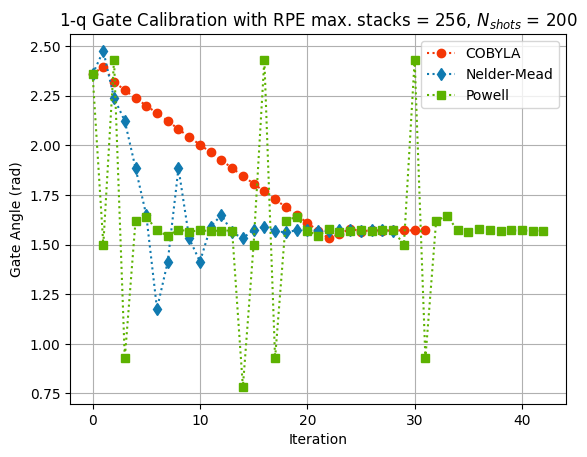

In [13]:
fig1 = plt.figure(1)
plt.clf()

plt.xlabel('Iteration')
plt.ylabel('Gate Angle (rad)')
plt.grid()
plt.title('1-q Gate Calibration with RPE max. stacks = %i, $N_{shots}$ = %i'%(2**max_exp, N))
plt.plot([r for r in range(0,len(COBYLA_estimated_angles))],COBYLA_estimated_angles,linestyle = ':', marker = 'o', color = 'xkcd:orangish red', label = 'COBYLA')
plt.plot([r for r in range(0,len(NM_estimated_angles))],NM_estimated_angles,linestyle = ':', marker = 'd', color = 'xkcd:nice blue', label = 'Nelder-Mead')
plt.plot([r for r in range(0,len(P_estimated_angles))],P_estimated_angles,linestyle = ':', marker = 's', color = 'xkcd:kermit green', label = 'Powell')
plt.legend()

plt.show()


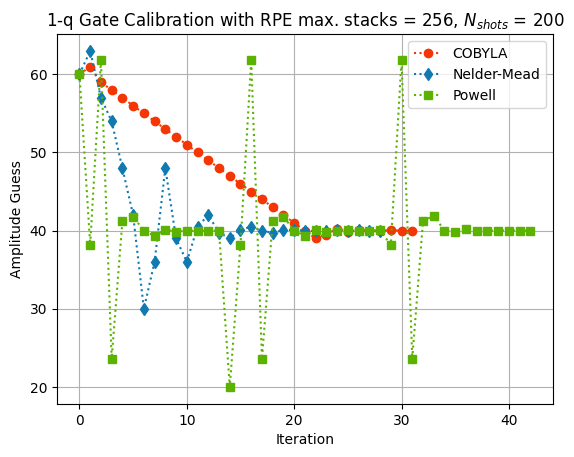

In [14]:
fig2 = plt.figure(2)
plt.clf()

plt.xlabel('Iteration')
plt.ylabel('Amplitude Guess')
plt.grid()
plt.title('1-q Gate Calibration with RPE max. stacks = %i, $N_{shots}$ = %i'%(2**max_exp, N))
plt.plot([r for r in range(0,len(COBYLA_test_amps))],COBYLA_test_amps,linestyle = ':', marker = 'o', color = 'xkcd:orangish red', label = 'COBYLA')
plt.plot([r for r in range(0,len(NM_test_amps))],NM_test_amps,linestyle = ':', marker = 'd', color = 'xkcd:nice blue', label = 'Nelder-Mead')
plt.plot([r for r in range(0,len(P_test_amps))],P_test_amps,linestyle = ':', marker = 's', color = 'xkcd:kermit green', label = 'Powell')
plt.legend()

plt.show()

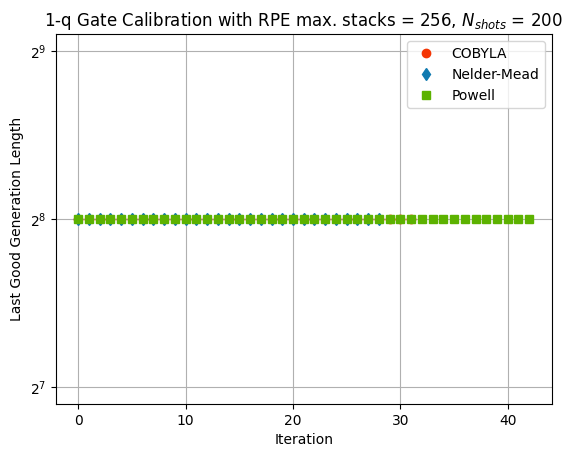

In [15]:
fig3 = plt.figure(3)
plt.clf()

plt.xlabel('Iteration')
plt.ylabel('Last Good Generation Length')
plt.yscale('log', base=2)
plt.grid()
plt.title('1-q Gate Calibration with RPE max. stacks = %i, $N_{shots}$ = %i'%(2**max_exp, N))
plt.plot([r for r in range(0,len(COBYLA_RPE_last_lengths))],COBYLA_RPE_last_lengths,linestyle = 'None', marker = 'o', color = 'xkcd:orangish red', label = 'COBYLA')
plt.plot([r for r in range(0,len(NM_RPE_last_lengths))],NM_RPE_last_lengths,linestyle = 'None', marker = 'd', color = 'xkcd:nice blue', label = 'Nelder-Mead')
plt.plot([r for r in range(0,len(P_RPE_last_lengths))],P_RPE_last_lengths,linestyle = 'None', marker = 's', color = 'xkcd:kermit green', label = 'Powell')
plt.legend()

plt.show()

In [ ]:
#For later!

#def qubit_mapping():
#    q0 = 2
#    q1 = 3
#    qn1 = 1
#    q2 = 6
#    qn2 = 7
#    q3 = 8
#    qn3 = 9 # Not connected yet.
#    monitor = 7
#    targets = [q0, q1, qn1, q2, qn2, q3, qn3]
#    return targets
#
#def nion_mask(nions):
#    nions=int(nions)
#    targets= qubit_mapping()
#    max_channels = 16
#    to_return = np.zeros((max_channels, ))
#    for i in range(nions):
#        to_return[targets[i]] = 1
#    # to_return[monitor] = 1
#    return to_return
  
